In [1]:
# pip install earthengine-api folium pandas numpy matplotlib

import ee
import folium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0. Authenticate / initialize Earth Engine
# ---------------------------------------------------------------------
# First time in a notebook: ee.Authenticate()
ee.Initialize()  # or ee.Initialize(project='your-gcp-project-id')

# ---------------------------------------------------------------------
# 1. Define AOI (Central Valley box, rounded to 2 decimals)
# ---------------------------------------------------------------------
coords_rounded = [[
    [-121.99, 38.75],
    [-121.99, 38.40],
    [-121.,  38.40],
    [-121.,  38.75],
    [-121.99, 38.75],  # close polygon
]]
aoi = ee.Geometry.Polygon(coords_rounded)

min_lon, max_lon = -121.99, -121.78
min_lat, max_lat = 38.50, 38.65
lat_mid = 0.5 * (min_lat + max_lat)
center_lon = 0.5 * (min_lon + max_lon)

# ---------------------------------------------------------------------
# 2. Load OpenET monthly ET and Landsat 8 LST for July 2020
# ---------------------------------------------------------------------
start = '2020-07-01'
end   = '2020-08-01'

# --- OpenET Ensemble Monthly ET (mm/month) ---
openet_ic = (
    ee.ImageCollection("OpenET/ENSEMBLE/CONUS/GRIDMET/MONTHLY/v2_0")
    .filterDate(start, end)
    .select('et_ensemble_mad')      # ensemble ET, mm
)
et_july = openet_ic.mosaic().clip(aoi)

# --- Landsat 8 Collection 2 L2 LST (ST_B10) → monthly mean °C ---
def apply_l8_st_scale(image):
    """Scale Landsat 8 C2 L2 ST_B10 to °C and add as LST_L8_C."""
    # K = DN * 0.00341802 + 149; °C = K - 273.15
    lst_c = (
        image.select('ST_B10')
        .multiply(0.00341802)
        .add(149.0)
        .add(-273.15)
        .rename('LST_L8_C')
    )
    return image.addBands(lst_c, None, True)

l8_ic = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate(start, end)
    .filter(ee.Filter.eq('PROCESSING_LEVEL', 'L2SP'))
    .map(apply_l8_st_scale)
)

lst_july_c = l8_ic.select('LST_L8_C').mean().clip(aoi)

# Combine into one image (for stats)
combo_img = et_july.addBands(lst_july_c)

# ---------------------------------------------------------------------
# 3. Helper: add Earth Engine Image layers to a Folium map
# ---------------------------------------------------------------------
def add_ee_layer(self, ee_image_object, vis_params, name):
    """Add an Earth Engine Image as a Folium TileLayer."""
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Map Data &copy; <a href=\"https://earthengine.google.com/\">Google Earth Engine</a>',
        name=name,
        overlay=True,
        control=True,
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer  # monkey-patch

# ---------------------------------------------------------------------
# 4. Make Folium map view
# ---------------------------------------------------------------------
m = folium.Map(
    location=[lat_mid, center_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)

et_vis = {
    'min': 0,
    'max': 250,
    'palette': ['blue', 'cyan', 'green', 'yellow', 'orange', 'red'],
}

lst_vis = {
    'min': 20,   # °C
    'max': 45,
    'palette': ['navy', 'blue', 'cyan', 'yellow', 'orange', 'red'],
}

m.add_ee_layer(et_july,    et_vis, 'OpenET July 2020 ET (mm)')
m.add_ee_layer(lst_july_c, lst_vis, 'Landsat 8 July 2020 LST (°C)')

# AOI rectangle
folium.Rectangle(
    bounds=[[min_lat, min_lon], [max_lat, max_lon]],
    color='black',
    weight=1,
    fill=False
).add_to(m)

# Transect line (east–west through the center)
folium.PolyLine(
    locations=[[lat_mid, min_lon], [lat_mid, max_lon]],
    color='black',
    weight=2,
).add_to(m)

# ---------------------------------------------------------------------
# 5. Load CDL and classify fallow/uncultivated/barren vs cultivated
# ---------------------------------------------------------------------
cdl2020 = (
    ee.ImageCollection('USDA/NASS/CDL')
    .filterDate('2020-01-01', '2021-01-01')
    .first()
    .clip(aoi)
)

# 'cultivated' band: 1 = non-cultivated, 2 = cultivated
cultivated_band = cdl2020.select('cultivated')

# 'cropland' band: 61 = Fallow/Idle Cropland, 65 & 131 = Barren
cropland = cdl2020.select('cropland')

fallow_barren = (
    cropland
    .remap(
        [61, 65, 131],  # fallow + barren classes
        [1,   1,   1],
        0               # all others 0
    )
    .rename('fallow_raw')
)

# Binary mask: non-cultivated OR explicit fallow/barren
fallow_uncultivated_mask = cultivated_band.eq(1).Or(fallow_barren.eq(1))

# --- Morphological opening to de-speckle (100 m circle) ---
kernel_100m = ee.Kernel.circle(200, 'meters')
fb_eroded = fallow_uncultivated_mask.focal_min(kernel=kernel_100m, iterations=1)
fb_opened = fb_eroded.focal_max(kernel=kernel_100m, iterations=1)

# Clean masks
fallow_clean_mask   = fb_opened            # boolean: 1 where fallow/uncultivated/barren (smoothed)
cultivated_mask     = cultivated_band.eq(2)  # boolean: 1 where cultivated

# Encode into classes: 1 = fallow/uncultivated/barren, 2 = cultivated
crop_class = (
    fallow_clean_mask.multiply(1)
    .add(cultivated_mask.multiply(2))
    .rename('fallow_vs_cultivated')
)

crop_class_masked = crop_class.updateMask(crop_class.neq(0))

crop_vis = {
    'min': 1,
    'max': 2,
    'palette': [
        '#ff9900',  # 1: fallow/uncultivated/barren
        '#006400',  # 2: cultivated
    ],
}

m.add_ee_layer(
    crop_class_masked,
    crop_vis,
    'Fallow/Uncultivated/Barren vs Cultivated (CDL 2020, cleaned)'
)

folium.LayerControl().add_to(m)

# In a notebook, show the map with:
m

# TODO: need to mask out urban areas here.
# maybe consider also hypothetical, compare to other estimated lengthscales.


In [2]:
# ---------------------------------------------------------------------
# 5b. Alternative: CDL classification with urban pixels masked out
# CDL codes: 121=Developed/Open Space, 122=Low, 123=Medium, 124=High Intensity
# Urban mask applied AFTER morphological opening so the erosion step is not affected.
# ---------------------------------------------------------------------

fallow_barren_urban = (
    cropland
    .remap(
        [61, 65, 131],
        [1,   1,   1],
        0
    )
    .rename('fallow_raw')
)

fallow_uncultivated_mask_urban = cultivated_band.eq(1).Or(fallow_barren_urban.eq(1))

kernel_200m = ee.Kernel.circle(200, 'meters')
fb_eroded_u = fallow_uncultivated_mask_urban.focal_min(kernel=kernel_200m, iterations=1)
fb_opened_u = fb_eroded_u.focal_max(kernel=kernel_200m, iterations=1)

# Zero out urban pixels after opening (avoids band-name issues with .And)
is_urban = (cropland.eq(121)
            .Or(cropland.eq(122))
            .Or(cropland.eq(123))
            .Or(cropland.eq(124)))
fallow_clean_mask_urban = fb_opened_u.where(is_urban, 0)

crop_class_urban = (
    fallow_clean_mask_urban.multiply(1)
    .add(cultivated_mask.multiply(2))
    .rename('fallow_vs_cultivated_urban_masked')
)
crop_class_urban_masked = crop_class_urban.updateMask(crop_class_urban.neq(0))

crop_vis_urban = {
    'min': 1,
    'max': 2,
    'palette': [
        '#ff9900',  # 1: fallow/uncultivated/barren (urban removed)
        '#006400',  # 2: cultivated
    ],
}

m_urban = folium.Map(
    location=[lat_mid, center_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)
m_urban.add_ee_layer(
    crop_class_urban_masked,
    crop_vis_urban,
    'Fallow/Uncultivated/Barren vs Cultivated (CDL 2020, urban masked)'
)
folium.Rectangle(
    bounds=[[min_lat, min_lon], [max_lat, max_lon]],
    color='black', weight=1, fill=False
).add_to(m_urban)
folium.LayerControl().add_to(m_urban)
m_urban


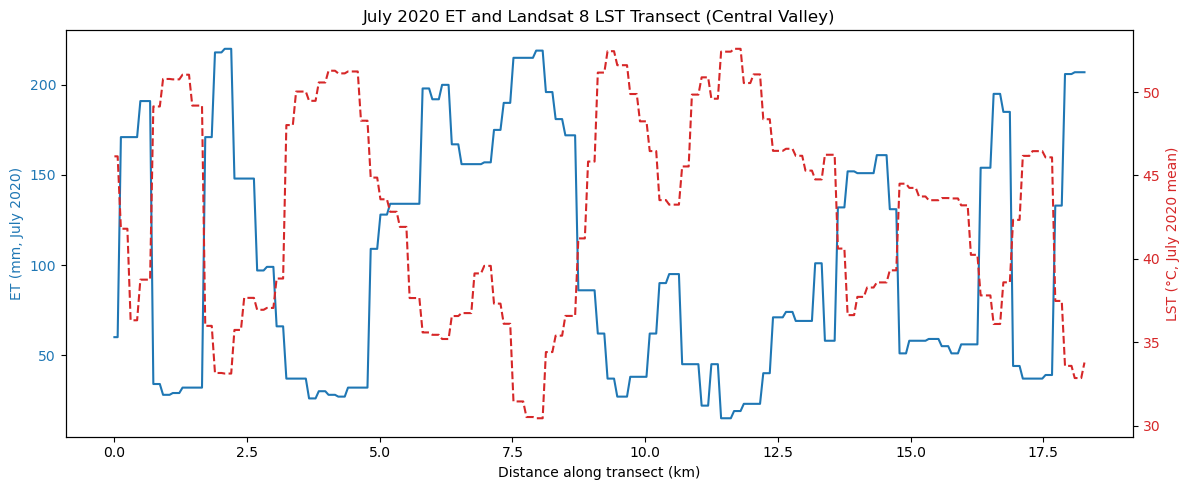

In [3]:

# 5. (Optional) Transect sampling for ET + Landsat LST
# ---------------------------------------------------------------------
def ee_fc_to_df(fc: ee.FeatureCollection) -> pd.DataFrame:
    """Convert an EE FeatureCollection to a pandas DataFrame."""
    fc_dict = fc.getInfo()
    rows = [f['properties'] for f in fc_dict['features']]
    return pd.DataFrame(rows)

# Build transect points
n_tran = 300
lons_tran = np.linspace(min_lon, max_lon, n_tran)
deg_to_km = 111.32 * np.cos(np.deg2rad(lat_mid))  # km per degree lon

tran_features = []
for lon in lons_tran:
    dist_km = (lon - min_lon) * deg_to_km
    pt = ee.Geometry.Point([float(lon), float(lat_mid)])
    feat = ee.Feature(pt, {'dist_km': float(dist_km)})
    tran_features.append(feat)

fc_tran = ee.FeatureCollection(tran_features)

samples_tran = combo_img.sampleRegions(
    collection=fc_tran,
    scale=250,
    geometries=False,
)

df_tran = ee_fc_to_df(samples_tran)
df_tran = df_tran[['dist_km', 'et_ensemble_mad', 'LST_L8_C']].dropna()
df_tran = df_tran.sort_values('dist_km')

# Plot transect
fig, ax1 = plt.subplots(figsize=(12, 5))

color1 = 'tab:blue'
color2 = 'tab:red'

ax1.set_xlabel('Distance along transect (km)')
ax1.set_ylabel('ET (mm, July 2020)', color=color1)
ax1.plot(df_tran['dist_km'], df_tran['et_ensemble_mad'],
         color=color1, label='ET (mm/month)')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.set_ylabel('LST (°C, July 2020 mean)', color=color2)
ax2.plot(df_tran['dist_km'], df_tran['LST_L8_C'],
         color=color2, linestyle='--', label='Landsat LST (°C)')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('July 2020 ET and Landsat 8 LST Transect (Central Valley)')
fig.tight_layout()
plt.show()


In [4]:

# ---------------------------------------------------------------------
# 6. (Optional) Mean ET & LST over fallow vs cultivated
# ---------------------------------------------------------------------
fallow_mask_img = crop_class.eq(1)
cultivated_mask_img = crop_class.eq(2)

fallow_stats = combo_img.updateMask(fallow_mask_img).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    tileScale=4
)
cultivated_stats = combo_img.updateMask(cultivated_mask_img).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    tileScale=4
)

fallow_stats_py = fallow_stats.getInfo()
cultivated_stats_py = cultivated_stats.getInfo()

print("Fallow / uncultivated / barren (July 2020):")
print(f"  Mean ET (mm/month): {fallow_stats_py.get('et_ensemble_mad')}")
print(f"  Mean LST (°C):      {fallow_stats_py.get('LST_L8_C')}")

print("\nCultivated (July 2020):")
print(f"  Mean ET (mm/month): {cultivated_stats_py.get('et_ensemble_mad')}")
print(f"  Mean LST (°C):      {cultivated_stats_py.get('LST_L8_C')}")

# ---------------------------------------------------------------------
# 7. How much cultivated land is within 200 m of a fallowed area?
# ---------------------------------------------------------------------
max_dist_m = 200

# Binary image of fallow/uncultivated/barren (0/1, no mask)
fallow_binary = fallow_clean_mask.unmask(0).gt(0)

# Distance (in meters) to nearest fallow pixel, up to 200 m
euclidean_kernel_200 = ee.Kernel.euclidean(max_dist_m, 'meters')
dist_to_fallow = fallow_binary.distance(euclidean_kernel_200)

# Cultivated pixels within 200 m of fallow
cultivated_within_200 = cultivated_mask.And(dist_to_fallow.lte(max_dist_m))

# Pixel area image (m^2)
pixel_area = ee.Image.pixelArea()

# Area of:
#  (a) cultivated land within 200 m of fallow
#  (b) all cultivated land in AOI
#  (c) all fallow/uncultivated/barren land
area_within_200 = pixel_area.updateMask(cultivated_within_200).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    tileScale=4
)
area_cultivated = pixel_area.updateMask(cultivated_mask).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    tileScale=4
)
area_fallow = pixel_area.updateMask(fallow_clean_mask).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=30,
    maxPixels=1e9,
    tileScale=4
)

area_within_200_m2 = area_within_200.get('area').getInfo()
area_cultivated_m2 = area_cultivated.get('area').getInfo()
area_fallow_m2     = area_fallow.get('area').getInfo()

area_within_200_km2 = area_within_200_m2 / 1e6
area_cultivated_km2 = area_cultivated_m2 / 1e6
area_fallow_km2     = area_fallow_m2 / 1e6

frac_cultivated_within_200 = area_within_200_m2 / area_cultivated_m2 if area_cultivated_m2 else float('nan')

print("\n--- Proximity analysis (within 200 m of fallow) ---")
print(f"Area fallow/uncultivated/barren: {area_fallow_km2:.3f} km²")
print(f"Area cultivated (total):         {area_cultivated_km2:.3f} km²")
print(f"Cultivated within 200 m fallow:  {area_within_200_km2:.3f} km²")
print(f"Fraction of cultivated within 200 m of fallow: {frac_cultivated_within_200:.3%}")


Fallow / uncultivated / barren (July 2020):
  Mean ET (mm/month): 75.03580886902843
  Mean LST (°C):      45.623057766309124

Cultivated (July 2020):
  Mean ET (mm/month): 132.65745495702794
  Mean LST (°C):      40.058295062372395

--- Proximity analysis (within 200 m of fallow) ---
Area fallow/uncultivated/barren: 1578.538 km²
Area cultivated (total):         1488.949 km²
Cultivated within 200 m fallow:  129.253 km²
Fraction of cultivated within 200 m of fallow: 8.681%


In [5]:
# ---------------------------------------------------------------------
# 8. Water saved by fallowing vs extra ET from advective enhancement
# ---------------------------------------------------------------------

# Mean ET values (mm/month)
ET_fallow_mm = fallow_stats_py.get('et_ensemble_mad')
ET_cult_mm   = cultivated_stats_py.get('et_ensemble_mad')

print("\n--- Mean ET recap ---")
print(f"Mean ET (fallow/uncultivated/barren): {ET_fallow_mm:.2f} mm/month")
print(f"Mean ET (cultivated):                 {ET_cult_mm:.2f} mm/month")

# Safety check in case any are None
if (ET_fallow_mm is None) or (ET_cult_mm is None):
    raise ValueError("Mean ET is None for fallow or cultivated; check masks / AOI.")

# -----------------------------
# 8.1 Water saved by fallowing
# -----------------------------
# Per-area ET difference (mm/month)
delta_ET_mm = ET_cult_mm - ET_fallow_mm

# Only count savings if cultivated ET > fallow ET
delta_ET_mm = max(delta_ET_mm, 0.0)

# Volume saved (m^3/month): (mm -> m) * area (m^2)
water_saved_m3 = (delta_ET_mm / 1000.0) * area_fallow_m2

# Convert to acre-feet (1 af = 1233.48 m^3)
water_saved_af = water_saved_m3 / 1233.48

print("\n--- Water saved by fallowing ---")
print(f"Per-area ET reduction: {delta_ET_mm:.2f} mm/month")
print(f"Total water saved:     {water_saved_m3:,.0f} m³/month")
print(f"                       {water_saved_af:,.2f} acre-feet/month")

# -------------------------------------------------------
# 8.2 Extra ET from advection on cultivated within 200 m
# -------------------------------------------------------
advective_factor = 0.20  # 20% enhancement

# Extra ET per area on cultivated-within-200m (mm/month)
extra_ET_mm = advective_factor * ET_cult_mm

# Volume (m^3/month)
extra_ET_m3 = (extra_ET_mm / 1000.0) * area_within_200_m2
extra_ET_af = extra_ET_m3 / 1233.48

print("\n--- Extra ET from advective enhancement (within 200 m) ---")
print(f"Assumed enhancement:   {advective_factor*100:.0f}% of cultivated ET")
print(f"Extra ET per area:     {extra_ET_mm:.2f} mm/month")
print(f"Extra ET volume:       {extra_ET_m3:,.0f} m³/month")
print(f"                       {extra_ET_af:,.2f} acre-feet/month")

# -----------------------
# 8.3 Net water “savings”
# -----------------------
net_saved_m3 = water_saved_m3 - extra_ET_m3
net_saved_af = net_saved_m3 / 1233.48

print("\n--- Net savings (fallow savings minus advective penalty) ---")
print(f"Net water saved:       {net_saved_m3:,.0f} m³/month")
print(f"                       {net_saved_af:,.2f} acre-feet/month")

print("Water lost/ Total water saved")
print(f"                       {(water_saved_af - net_saved_af)/water_saved_af:,.2f}")



--- Mean ET recap ---
Mean ET (fallow/uncultivated/barren): 75.04 mm/month
Mean ET (cultivated):                 132.66 mm/month

--- Water saved by fallowing ---
Per-area ET reduction: 57.62 mm/month
Total water saved:     90,957,950 m³/month
                       73,740.92 acre-feet/month

--- Extra ET from advective enhancement (within 200 m) ---
Assumed enhancement:   20% of cultivated ET
Extra ET per area:     26.53 mm/month
Extra ET volume:       3,429,277 m³/month
                       2,780.16 acre-feet/month

--- Net savings (fallow savings minus advective penalty) ---
Net water saved:       87,528,673 m³/month
                       70,960.76 acre-feet/month
Water lost/ Total water saved
                       0.04


Let:

- `ET_cult` = mean monthly ET over cultivated land (mm/month)  
- `ET_fallow` = mean monthly ET over fallowed/uncultivated/barren land (mm/month)  
- `A_fallow` = area of fallowed land (m²)  
- `A_near` = cultivated area within 200 m of a fallowed pixel (m²)  
- `f` = advective enhancement factor (here `f = 0.2` for 20%)  
- `1 af = 1233.48 m³` (acre-feet conversion)

**1. Water saved by fallowing**

Per-area ET reduction:

$$
\Delta ET = ET_{\text{cult}} - ET_{\text{fallow}} \quad (\text{mm/month})
$$

Volume saved:

$$
V_{\text{saved}} = \frac{\Delta ET}{1000} \, A_{\text{fallow}} \quad (\text{m}^3/\text{month})
$$

In acre-feet:

$$
V_{\text{saved, af}} = \frac{V_{\text{saved}}}{1233.48}
$$

**2. Extra ET due to advection near fallow**

Assuming 20% enhancement on cultivated pixels within 200 m of fallow:

$$
ET_{\text{extra}} = f \, ET_{\text{cult}} \quad (\text{mm/month})
$$

Volume of extra ET:

$$
V_{\text{adv}} = \frac{f \, ET_{\text{cult}}}{1000} \, A_{\text{near}} \quad (\text{m}^3/\text{month})
$$

In acre-feet:

$$
V_{\text{adv, af}} = \frac{V_{\text{adv}}}{1233.48}
$$

**3. Net savings**

$$
V_{\text{net}} = V_{\text{saved}} - V_{\text{adv}}
$$

$$
V_{\text{net, af}} = V_{\text{saved, af}} - V_{\text{adv, af}}
$$


Think about “tightening” this:

(a) make the classification more defensible,

(b) make the ET contrasts more specific and less assumption-heavy, and

(c) make the advection term more data-driven and less made-up (20%).

In [6]:
# --- ORIGINAL classification (CDL 2020 only) ---
cdl2020 = (
    ee.ImageCollection('USDA/NASS/CDL')
    .filterDate('2020-01-01', '2021-01-01')
    .first()
    .clip(aoi)
)

cropland_2020 = cdl2020.select('cropland')
cultivated_band_2020 = cdl2020.select('cultivated')  # 1 = non-cultivated, 2 = cultivated

# Fallow / barren codes in CDL
#  61 = Fallow/Idle Cropland
#  65 = Barren
# 131 = Barren
fallow_barren_2020 = (
    cropland_2020
    .remap(
        [61, 65, 131],
        [1,  1,   1],
        0
    )
)

# "Original" fallow/uncultivated = non-cultivated OR explicit fallow/barren
fallow_uncultivated_orig = cultivated_band_2020.eq(1).Or(fallow_barren_2020.eq(1))

# Morphological opening (100 m circle) to de-speckle
kernel_100m = ee.Kernel.circle(100, 'meters')
fb_eroded_o = fallow_uncultivated_orig.focal_min(kernel=kernel_100m, iterations=1)
fb_opened_o = fb_eroded_o.focal_max(kernel=kernel_100m, iterations=1)

orig_fallow_mask = fb_opened_o
orig_cultivated_mask = cultivated_band_2020.eq(2)

orig_crop_class = (
    orig_fallow_mask.multiply(1)
    .add(orig_cultivated_mask.multiply(2))
    .updateMask(orig_fallow_mask.Or(orig_cultivated_mask))
    .rename('orig_fallow_vs_cultivated')
)


In [7]:
# --- IMPROVED classification ---
# Idea:
#  - Historically cropland = cropland in >= N baseline years (by cropland codes only)
#  - Drought-fallowed cropland in 2020 = historically cropland but NON-cultivated in 2020
#  - Cultivated cropland in 2020 = historically cropland AND cultivated in 2020

# Improved classification image:
#   1 = drought-fallowed cropland
#   2 = cultivated cropland in 2020 (historically cropland)

baseline_years = [2016, 2017, 2018, 2019]
min_baseline_presence = 2  # cropland in >= 2 baseline years

# Define cropland codes (example: 1-60, adjust as needed)
cropland_codes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]

def get_cropland_mask(img):
    return img.select('cropland').remap(cropland_codes, [1]*len(cropland_codes), 0).eq(1)

baseline_cropland_masks = []
for year in baseline_years:
    cdl_y = (
        ee.ImageCollection('USDA/NASS/CDL')
        .filterDate(f'{year}-01-01', f'{year+1}-01-01')
        .first()
        .clip(aoi)
    )
    cropland_mask_y = get_cropland_mask(cdl_y)  # based on cropland codes only
    baseline_cropland_masks.append(cropland_mask_y)

# "Historically cropland" = cropland in >= min_baseline_presence baseline years
hist_cropland_count = ee.ImageCollection(baseline_cropland_masks).sum()
hist_cropland = hist_cropland_count.gte(min_baseline_presence)

# 2020 cropland + cultivated bands
cropland_mask_2020 = get_cropland_mask(cdl2020)
cultivated_2020 = cultivated_band_2020.eq(2)

# Drought-fallowed cropland in 2020:
drought_fallow_raw = (
    hist_cropland
    .And(cropland_mask_2020)
    .And(cultivated_2020.Not())
)

# Cultivated cropland in 2020 that is historically cropland
cultivated_hist_2020 = (
    hist_cropland
    .And(cropland_mask_2020)
    .And(cultivated_2020)
)

# Morphological opening (100 m circle) on drought-fallow
kernel_100m = ee.Kernel.circle(100, 'meters')
df_eroded = drought_fallow_raw.focal_min(kernel=kernel_100m, iterations=1)
df_opened = df_eroded.focal_max(kernel=kernel_100m, iterations=1)

# Optional patch-size filter: keep only patches ≥ N pixels (e.g. ~1 ha)
min_patch_pixels = 10  # ~0.9 ha at 30 m
df_cc = df_opened.selfMask().connectedPixelCount(
    maxSize=1024,
    eightConnected=True
)

drought_fallow_mask = df_opened.updateMask(df_cc.gte(min_patch_pixels))

impr_crop_class = (
    drought_fallow_mask.multiply(1)
    .add(cultivated_hist_2020.multiply(2))
    .updateMask(drought_fallow_mask.Or(cultivated_hist_2020))
    .rename('impr_droughtfallow_vs_cultivated')
)

In [8]:
# --- Area comparison ---
pixel_area = ee.Image.pixelArea()

def area_by_class(class_img, value):
    """Total area (m²) where class_img == value within AOI."""
    area_img = pixel_area.updateMask(class_img.eq(value))
    return area_img.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        tileScale=4
    ).get('area')

# Original areas
area_orig_fallow_m2 = area_by_class(orig_crop_class, 1)
area_orig_cult_m2   = area_by_class(orig_crop_class, 2)

# Improved areas
area_impr_fallow_m2 = area_by_class(impr_crop_class, 1)
area_impr_cult_m2   = area_by_class(impr_crop_class, 2)

area_orig_fallow = ee.Number(area_orig_fallow_m2).getInfo()
area_orig_cult   = ee.Number(area_orig_cult_m2).getInfo()
area_impr_fallow = ee.Number(area_impr_fallow_m2).getInfo()
area_impr_cult   = ee.Number(area_impr_cult_m2).getInfo()

# Convert to km²
orig_fallow_km2 = area_orig_fallow / 1e6
orig_cult_km2   = area_orig_cult / 1e6
impr_fallow_km2 = area_impr_fallow / 1e6
impr_cult_km2   = area_impr_cult / 1e6

print("Original classification (CDL 2020 only):")
print(f"  Fallow / uncultivated / barren: {orig_fallow_km2:.3f} km²")
print(f"  Cultivated:                    {orig_cult_km2:.3f} km²")

print("\nImproved classification (historically cropland → drought fallow 2020):")
print(f"  Drought-fallowed cropland:     {impr_fallow_km2:.3f} km²")
print(f"  Cultivated cropland 2020:      {impr_cult_km2:.3f} km²")


Original classification (CDL 2020 only):
  Fallow / uncultivated / barren: 1680.255 km²
  Cultivated:                    1428.424 km²

Improved classification (historically cropland → drought fallow 2020):
  Drought-fallowed cropland:     4.383 km²
  Cultivated cropland 2020:      0.000 km²


In [9]:
# --- Folium map to compare masks ---
m = folium.Map(
    location=[lat_mid, center_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)

orig_vis = {
    'min': 1,
    'max': 2,
    'palette': ['#ffcc00', '#006400'],  # 1: fallow, 2: cultivated
}
impr_vis = {
    'min': 1,
    'max': 2,
    'palette': ['#ff6600', '#009900'],  # 1: drought-fallow, 2: cultivated
}

m.add_ee_layer(
    orig_crop_class,
    orig_vis,
    'Original fallow vs cultivated (CDL 2020 only)'
)

m.add_ee_layer(
    impr_crop_class,
    impr_vis,
    'Improved drought-fallow vs cultivated (multi-year CDL)'
)

# AOI outline
folium.Rectangle(
    bounds=[[min_lat, min_lon], [max_lat, max_lon]],
    color='black',
    weight=1,
    fill=False
).add_to(m)

folium.LayerControl().add_to(m)

# In a notebook, show:
m


## Notes on OpenET

Why ET edges look sharper than Landsat LST 



ET is strongly tied to field boundaries; LST less so

Most OpenET models use Landsat optical reflectance + thermal and effectively lock on to field-scale patterns (NDVI, albedo, canopy fraction, crop type). Those inputs are very crisp at 30 m, so ET tends to jump at parcel boundaries.

Landsat LST layer is coming  from TIRS, which has a native ~100 m footprint resampled to 30 m. Thermal PSF + atmospheric noise + monthly averaging all smooth temperature gradients, so boundaries look softer.

ET uses more than just temperature.

Energy-balance models redistribute energy between sensible and latent heat using temperature and vegetation/roughness differences, so two fields with similar LST but very different NDVI can have quite different ET.


SIMS (the reflectance-based model) doesn’t use thermal; 
it drives ET from canopy density + crop coefficients, which are very field-sharp.



Landsat is currently the primary satellite dataset used within the OpenET platform. 
The Landsat program, a joint program of the U.S. Geological Survey and NASA, 
provides the longest continuous space-based record of Earth’s land in existence, 
dating back to 1972 for optical data and to 1982 for thermal data. 

Landsat is the only operational satellite that combines thermal and optical data 
at the spatial resolution needed to assess water use and water rights, 
which is often at the level of individual agricultural fields.

Multiple models implemented within the OpenET framework also integrate data from 
GOES, Sentinel-2, Suomi NPP, Terra, Aqua and other satellites to produce 
ET data at a range of spatial and temporal scales.

Along with satellite-based observations of the Earth’s surface, 
OpenET also uses weather station measurements across the country
that are integrated into assimilation systems to produce spatially 
distributed or gridded weather datasets, 
such as gridMET, Spatial CIMIS, DAYMET, PRISM, and NLDAS. 

These datasets are used within the OpenET platform for various 
model parameters and variables, such as atmospheric stability, 
net radiation, and surface air temperature gradients. 

One of the primary variables derived from gridded weather data is
the reference ET, which is the amount of ET from a reference surface, 
typically a well-watered grass or alfalfa crop. 

OpenET uses reference ET data calculated using the 
American Society of Civil Engineers (ASCE) Standardized 
Penman-Monteith equation for a grass reference surface, 
and usually notated as ‘ETo’. 

Reference ET data are used to support the calculation of actual ET 
between Landsat satellite overpasses, which occur every eight days
(excepting cloud cover) with two Landsat satellites in orbit.

First, the fraction of reference ET for each satellite overpass date
is calculated by dividing the satellite ET on the overpass date 
by the reference ET. Fraction of reference ET values are then 
linearly interpolated on a daily timestep for all days between 
clear satellite overpass dates, one image pixel at a time, and
are then multiplied by the daily reference ET values to calculate
a daily time series of actual ET for every pixel. These per-pixel daily 
time series of actual ET are then aggregated to monthly and annual 
time periods. The fraction of reference ET is interpolated in
time because it tends to change in proportion to changes in vegetation cover,
similar to its equivalent, the widely used crop coefficient. 

Daily reference ET is then used to reintroduce the impacts of 
day to day changes in weather on actual ET rates.



For California, OpenET uses Spatial CIMIS meteorological datasets 
generated by the California Department of Water Resources  to compute ASCE grass reference ET. 

For other states, OpenET calculates ASCE grass reference
ET using meteorological inputs from the gridMET dataset. 

To ensure that gridded reference ET data are representative
of agricultural weather conditions, 
nearly 800 weather stations located in agricultural areas are filtered, 
quality controlled and then used by OpenET for bias correction of
gridded reference ET calculated from gridMET within these areas. 

Bias correction of calculated reference ET accounts for
effects of deviations in gridMET wind speed, solar radiation, 
humidity and air temperature data from local weather station data,
as well as for aridity biases that can exist in gridded weather data sets.

Weather station data are passed through rigorous quality assurance and quality control procedures following ASCE and FAO guidelines prior to calculation of reference ET. 

Ancillary data used by the OpenET platform include 
crop type information from the U.S. Department of Agriculture (USDA) and state agencies, 
USDA soils data,
U.S. Geological Survey (USGS) digital elevation models, 
USGS land use classifications, active irrigated lands datasets, 
and manually digitized agricultural field boundaries from USDA, state agencies, and research groups.

The OpenET science teams are currently evaluating data pre-processing and time integration techniques to further improve the accuracy of ET estimates, as well as exploring the accuracy improvements associated with having more frequent thermal and optical satellite imagery. 


Driving all models with communnity-selected and more frequent datasets for pre-processing and time integration techniques has increased the accuracy and consistency and reduced the range of ET estimates among the different models.

## TODO: Understand this. https://etdata.org/methodologies/